# 🌌 Schrödinger Multi‑Futuro: Superposición Cuántica de Trayectorias en Sistemas Dinámicos

## 1. Introducción y Fundamento Físico
En mecánica cuántica, un sistema físico permanece en una **superposición lineal de estados** hasta que una interacción con el entorno (medición) provoca el **colapso de la función de onda**. Aquí extrapolamos esta formulación al campo de los sistemas dinámicos caóticos mediante un filtro de multiverso predictivo.

## 2. Formalismo Matemático en Espacio de Hilbert Artificial

### 2.1 Estado de Superposición Predictiva
Definimos el estado cuántico global predictivo $|Ψ(t)\rangle$ como la combinación lineal de $N$ trayectorias o futuros paralelos ortogonales:

$$|Ψ(t)\rangle = \sum_{i=1}^{N} c_i(t) \, |\psi_i(t)\rangle$$

Donde:
* $|\psi_i(t)\rangle \in \mathbb{R}^d$ es el vector de estado clásico de la trayectoria $i$ (por ejemplo, las coordenadas del atractor de Lorenz).
* $c_i(t) \in \mathbb{C}$ representa la **amplitud de probabilidad** cuántica asociada a ese futuro particular.

Para preservar la consistencia estadística de la regla de Born, el estado global debe cumplir estrictamente con la condición de normalización:

$$\sum_{i=1}^{N} |c_i(t)|^2 = 1$$

### 2.2 Evolución Temporal Mediante Operadores Unitarios
Entre cada intervalo de medición $\Delta t$, cada una de las ramas evoluciona de manera independiente gobernada por la ecuación diferencial de Schrödinger dependiente del tiempo:

$$i\hbar \frac{\partial}{\partial t}|\psi_i(t)\rangle = \hat{H}_i |\psi_i(t)\rangle$$

La integración exacta de este estado se modela mediante la aplicación de un operador unitario de evolución (propagador cuántico):

$$|\psi_i(t+\Delta t)\rangle = \hat{U}_i(\Delta t) \, |\psi_i(t)\rangle = \exp\left(-\frac{i}{\hbar} \hat{H}_i \Delta t\right) |\psi_i(t)\rangle$$

### 2.3 Medición, Verosimilitud Bayesiana y Colapso Cuántico
Cuando el sistema real genera una observación ruidosa $\mathbf{z}_t$, evaluamos qué tan compatible es cada universo utilizando una función de observación $h(\cdot)$ bajo un proyector de densidad gaussiano:

$$\mathcal{L}_i(\mathbf{z}_t) = P(\mathbf{z}_t | |\psi_i\rangle) = \frac{1}{\sqrt{(2\pi)^m |\mathbf{\Sigma}|}} \exp \left( -\frac{1}{2} \big(\mathbf{z}_t - h(|\psi_i\rangle)\big)^T \mathbf{\Sigma}^{-1} \big(\mathbf{z}_t - h(|\psi_i\rangle)\big) \right)$$

Posteriormente, actualizamos de forma continua el vector de amplitudes complejas acoplando la probabilidad clásica a la fase cuántica:

$$c_i(t^+) = \frac{c_i(t^-) \sqrt{\mathcal{L}_i(\mathbf{z}_t)}}{\sqrt{\sum_{j=1}^N |c_j(t^-)|^2 \mathcal{L}_j(\mathbf{z}_t)}}$$

Finalmente, se ejecuta el **colapso cuántico instantáneo**, forzando al sistema a converger hacia la rama con mayor densidad de probabilidad acumulada:

$$|\Psi(t^+)\rangle \longrightarrow |\psi_{k}(t)\rangle$$

In [3]:
# =============================================================================
# EXPLICACIÓN: Importamos las librerías científicas estándar. Usamos 'odeint'
# para resolver numéricamente las ecuaciones diferenciales ordinarias (ODEs)
# no lineales del Atractor Caótico de Lorenz.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def lorenz_deriv(state, t, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

def lorenz_step(state, dt, sigma, rho, beta):
    """Un paso de integración numérica para el sistema de Lorenz."""
    t = np.array([0, dt])
    sol = odeint(lorenz_deriv, state, t, args=(sigma, rho, beta))
    return sol[1]

In [4]:
# =============================================================================
# EXPLICACIÓN: Esta clase implementa el Espacio de Hilbert artificial.
# Inicializa N estados paralelos, gestiona su evolución temporal en paralelo
# y aplica la reducción/colapso cuántico basándose en mediciones externas.
# =============================================================================

import numpy as np

class BayesianSuperposition:
    """
    Mantiene N hipótesis (universos) con sus respectivas probabilidades.
    La estimación se obtiene como promedio ponderado de los estados.
    Incluye remuestreo sistemático para evitar degeneración de pesos.
    """
    def __init__(self, n_futures, dim, dt, propagators):
        self.n = n_futures
        self.dim = dim
        self.dt = dt
        self.propagators = propagators
        self.states = [np.zeros(dim) for _ in range(n_futures)]
        self.weights = np.ones(n_futures) / n_futures

    def initialize(self, initial_state):
        for i in range(self.n):
            self.states[i] = initial_state.copy()
        self.weights = np.ones(self.n) / self.n

    def evolve(self):
        """Evoluciona cada hipótesis con su propio propagador."""
        for i, prop in enumerate(self.propagators):
            self.states[i] = prop(self.states[i], self.dt)

    def update(self, observation, obs_function, noise_std, eps=1e-100):
        """
        Actualiza los pesos según verosimilitud gaussiana.
        Luego aplica remuestreo sistemático.
        Retorna el estado estimado (promedio ponderado).
        """
        # Calcular verosimilitudes
        likelihoods = np.array([
            np.exp(-0.5 * np.sum(((observation - obs_function(s)) / noise_std)**2))
            for s in self.states
        ])
        # Evitar ceros absolutos (underflow)
        likelihoods = np.maximum(likelihoods, eps)

        # Actualización bayesiana
        self.weights *= likelihoods
        total = np.sum(self.weights)
        if total > 0:
            self.weights /= total
        else:
            # Reiniciar en caso de underflow extremo
            self.weights = np.ones(self.n) / self.n

        # Remuestreo sistemático (evita degeneración)
        cum_weights = np.cumsum(self.weights)
        indices = np.searchsorted(cum_weights, np.random.random(self.n))
        self.states = [self.states[i] for i in indices]
        self.weights = np.ones(self.n) / self.n

        # Estimación por promedio ponderado (más eficiente)
        estimated = np.average(self.states, axis=0, weights=self.weights)
        return estimated

In [5]:
# Parámetros nominales del atractor de Lorenz
SIGMA_NOM = 10.0
RHO_NOM = 28.0
BETA_NOM = 8.0/3.0

# Generamos 5 universos con pequeñas variaciones en sigma y rho
n_universes = 5
params = []
for i in range(n_universes):
    sigma = SIGMA_NOM + 0.2 * (i - n_universes//2)   # -0.4, -0.2, 0, +0.2, +0.4
    rho = RHO_NOM + 0.5 * (i - n_universes//2)       # -1.0, -0.5, 0, +0.5, +1.0
    beta = BETA_NOM
    params.append((sigma, rho, beta))

# Creamos los propagadores como funciones que usan los parámetros específicos
def make_propagator(sigma, rho, beta):
    return lambda state, dt: lorenz_step(state, dt, sigma, rho, beta)

propagators = [make_propagator(s, r, b) for (s, r, b) in params]

# Función de observación: medimos las primeras dos componentes (X, Y)
def observation_function(state):
    return state[:2]

In [6]:
dt = 0.01
steps = 1000
initial_state = np.array([1.0, 1.0, 20.0])

# Generar trayectoria verdadera con ruido de proceso
true_trajectory = []
current_true = initial_state.copy()
np.random.seed(42)
for _ in range(steps):
    current_true = lorenz_step(current_true, dt, SIGMA_NOM, RHO_NOM, BETA_NOM)
    current_true += np.random.normal(0, 0.05, size=3)   # ruido de proceso
    true_trajectory.append(current_true.copy())
true_trajectory = np.array(true_trajectory)

# Inicializar filtro
bf = BayesianSuperposition(n_futures=n_universes, dim=3, dt=dt, propagators=propagators)
bf.initialize(initial_state)

# Bucle de filtrado
estimated_trajectory = []
history_weights = []   # para guardar evolución de pesos (opcional)

for t_idx in range(steps):
    bf.evolve()

    # Observación ruidosa de X e Y (ruido con desviación 2.0)
    z = true_trajectory[t_idx, :2] + np.random.normal(0, 2.0, size=2)
    estim = bf.update(z, observation_function, noise_std=2.0)
    estimated_trajectory.append(estim)
    history_weights.append(bf.weights.copy())

estimated_trajectory = np.array(estimated_trajectory)

# Métricas de error
mse = np.mean((true_trajectory - estimated_trajectory)**2, axis=0)
print("=" * 50)
print("📊 INFORME DE PRECISIÓN (Filtro Bayesiano sin colapso)")
print("=" * 50)
print(f"MSE en X: {mse[0]:.6f}")
print(f"MSE en Y: {mse[1]:.6f}")
print(f"MSE en Z (no observada): {mse[2]:.6f}")
print("=" * 50)

📊 INFORME DE PRECISIÓN (Filtro Bayesiano sin colapso)
MSE en X: 100.115949
MSE en Y: 135.414854
MSE en Z (no observada): 144.552640


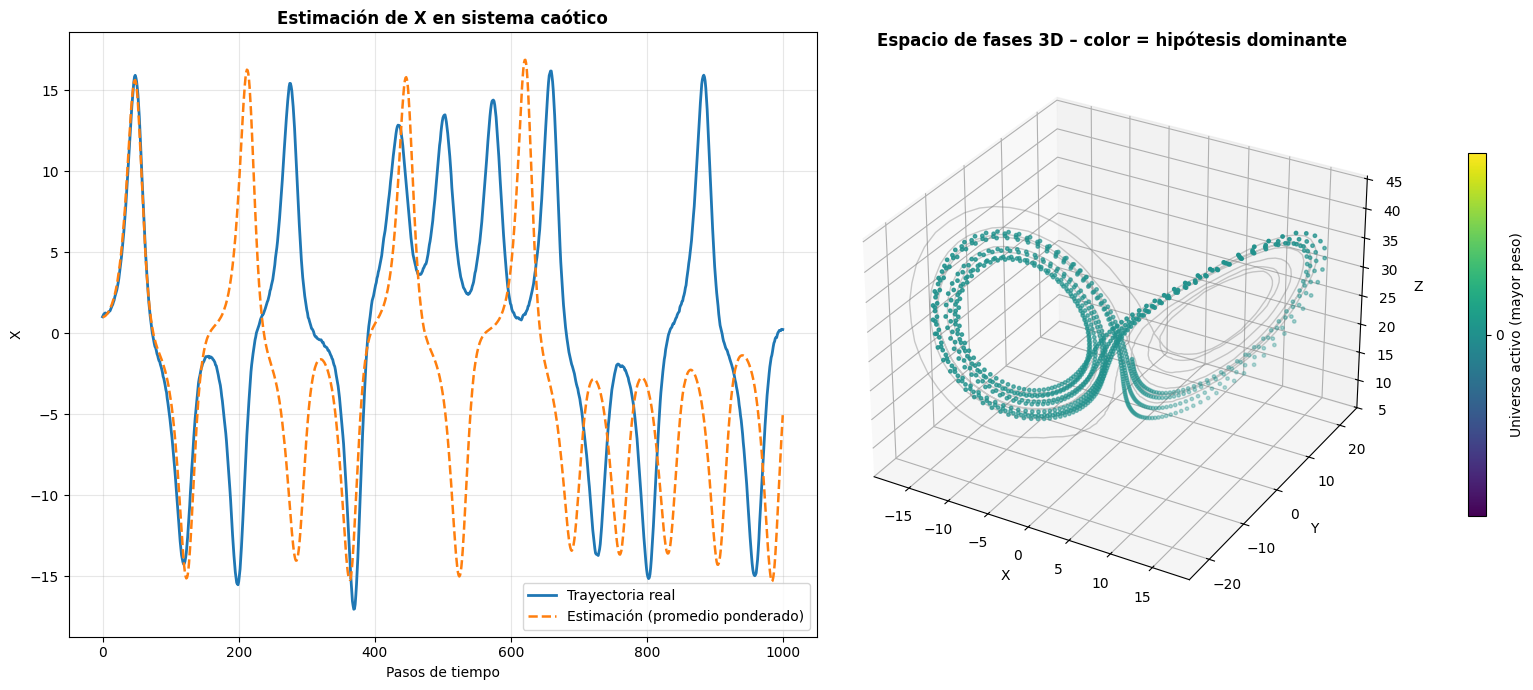

In [7]:
fig = plt.figure(figsize=(16, 7))

# Subplot 1: Evolución temporal de X
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(true_trajectory[:, 0], label='Trayectoria real', color='#1f77b4', lw=2)
ax1.plot(estimated_trajectory[:, 0], label='Estimación (promedio ponderado)', color='#ff7f0e', linestyle='--', lw=1.8)
ax1.set_title('Estimación de X en sistema caótico', fontsize=12, fontweight='bold')
ax1.set_xlabel('Pasos de tiempo')
ax1.set_ylabel('X')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Atractor 3D coloreado por la hipótesis dominante
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(true_trajectory[:, 0], true_trajectory[:, 1], true_trajectory[:, 2],
         label='Flujo real', color='gray', alpha=0.4, lw=1)

# Identificamos la hipótesis con mayor peso en cada instante
dominant_hyp = np.argmax(history_weights, axis=1)
scatter = ax2.scatter(estimated_trajectory[:, 0], estimated_trajectory[:, 1], estimated_trajectory[:, 2],
                      c=dominant_hyp, cmap='viridis', s=6, label='Estimación')
ax2.set_title('Espacio de fases 3D – color = hipótesis dominante', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
cbar = fig.colorbar(scatter, ax=ax2, pad=0.1, shrink=0.6, ticks=range(n_universes))
cbar.set_label('Universo activo (mayor peso)')
plt.tight_layout()
plt.show()